Dataset: 12032 samples, model=qwen2
Student accuracy: 0.362
Teacher accuracy: 0.734
High-Value:     4901 (40.7%)
Both correct:   3933 (32.7%)
Both wrong:     2776 (23.1%)
Student>Teach:   422 (3.5%)

Entropy ranges: H(s) ∈ [0, 2.23], H(t) ∈ [0, 2.26]
After normalization: Ĥ(s), Ĥ(t) ∈ [0, 1]
Raw 1-H(t) < 0: 2814 samples (23.4%) — broken without norm
Norm 1-Ĥ(t) < 0: 0 samples — none


  RANKING TABLE — top 5%
Metric                             HV%   Learn%   Noisy%   S.Acc   T.Acc     Lift
--------------------------------------------------------------------------------------------------------------
 1. SNR: H²(s)/H²(t)             68.1%    94.0%     6.0%   27.0%   94.0%   +68.3%
 2. H(s)/(1−P(t))                67.9%    94.2%     5.8%   27.3%   94.2%   +67.9%
 3. H(s)−H(t)                    64.7%    83.4%    16.6%   21.1%   83.4%   +60.1%
 4. BALD+ = max(0,H(s)−H(t))     64.7%    83.4%    16.6%   21.1%   83.4%   +60.1%
 5. Ĥ(s)·(1−Ĥ(t))                62.1%    79.9%    20.1%   21.1%   

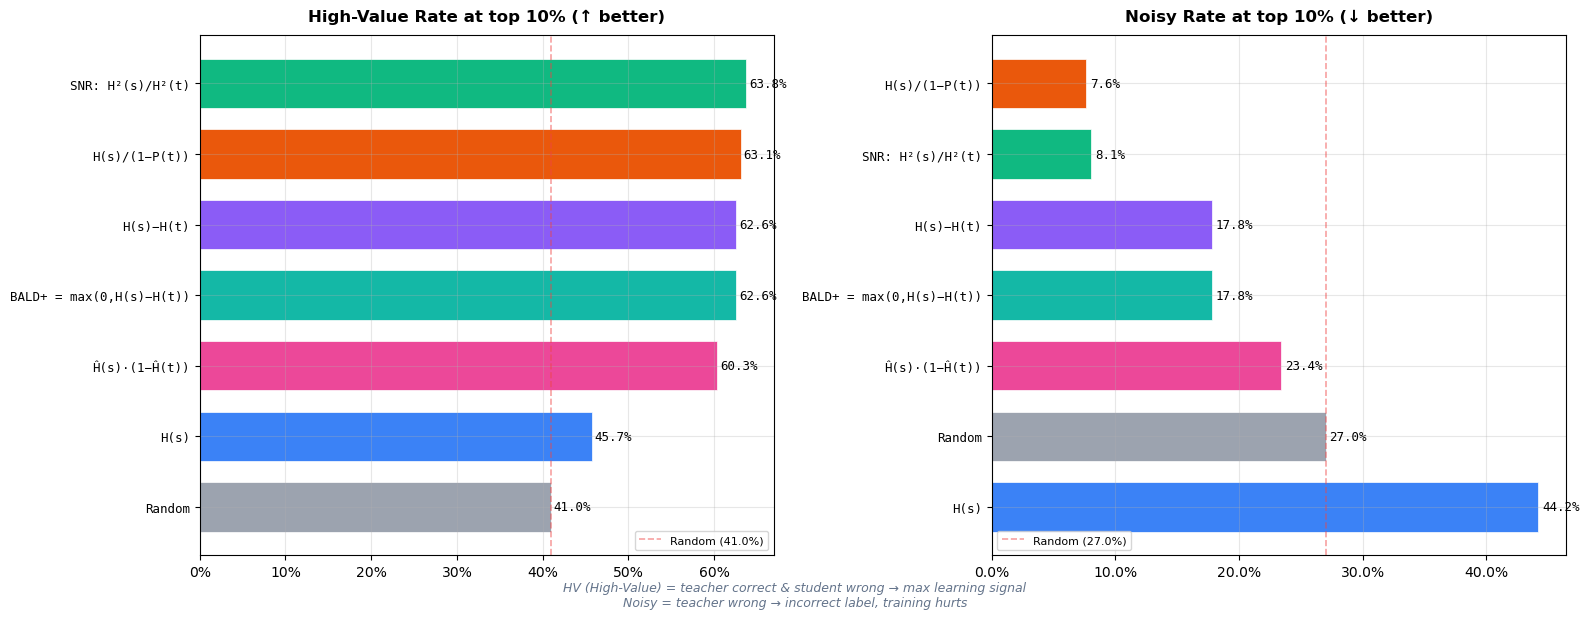

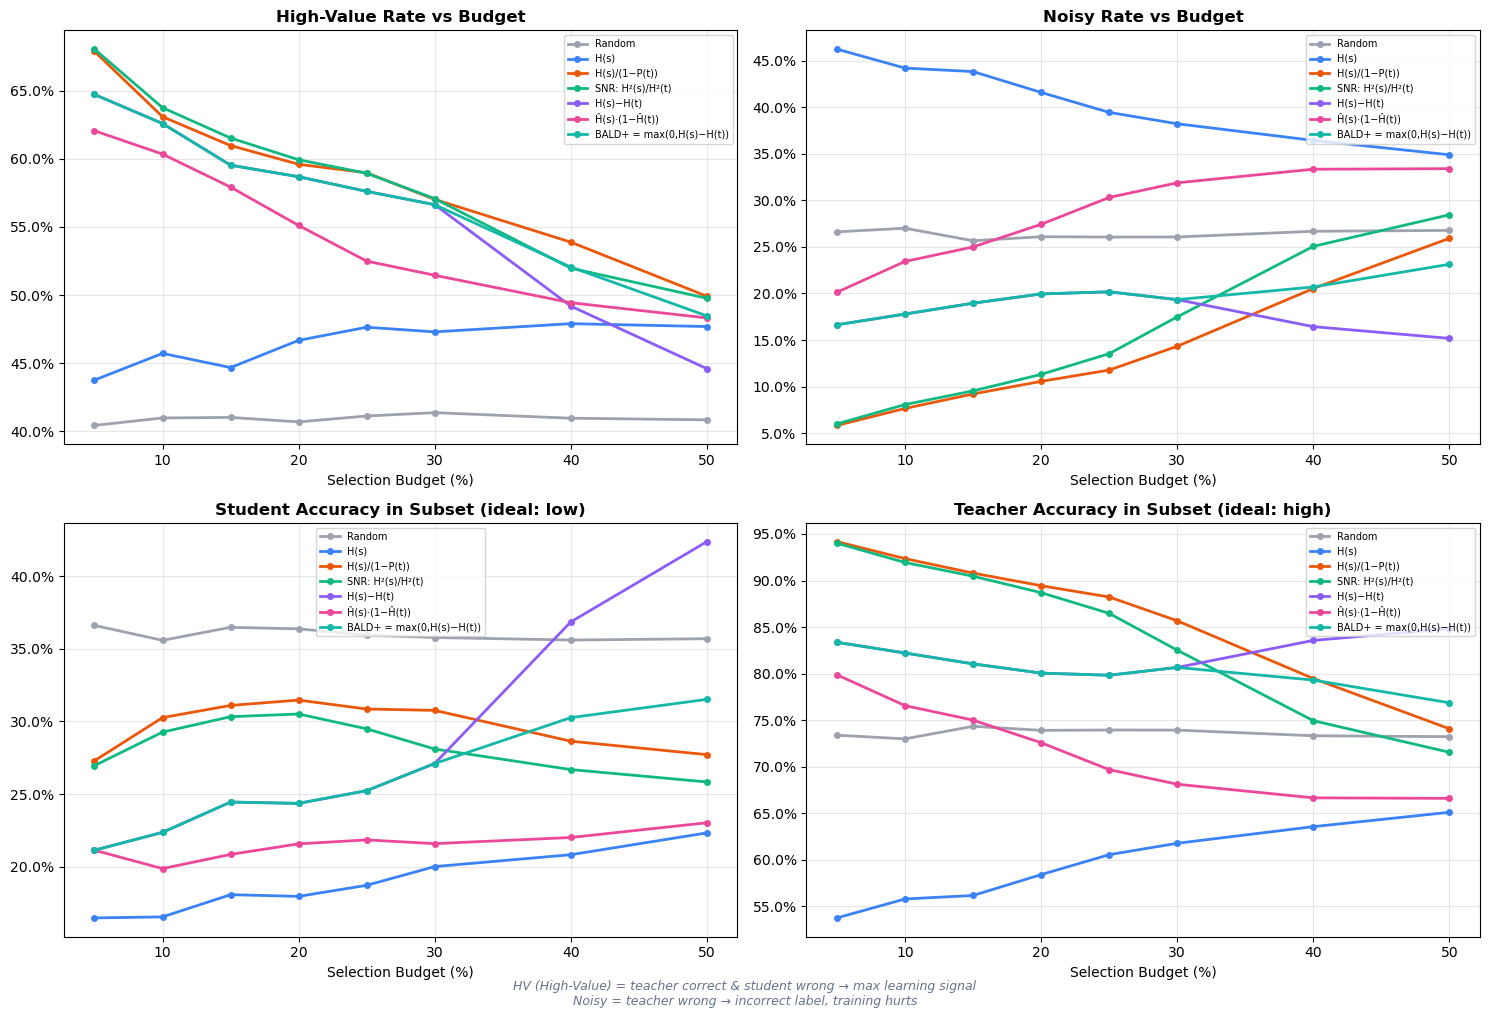

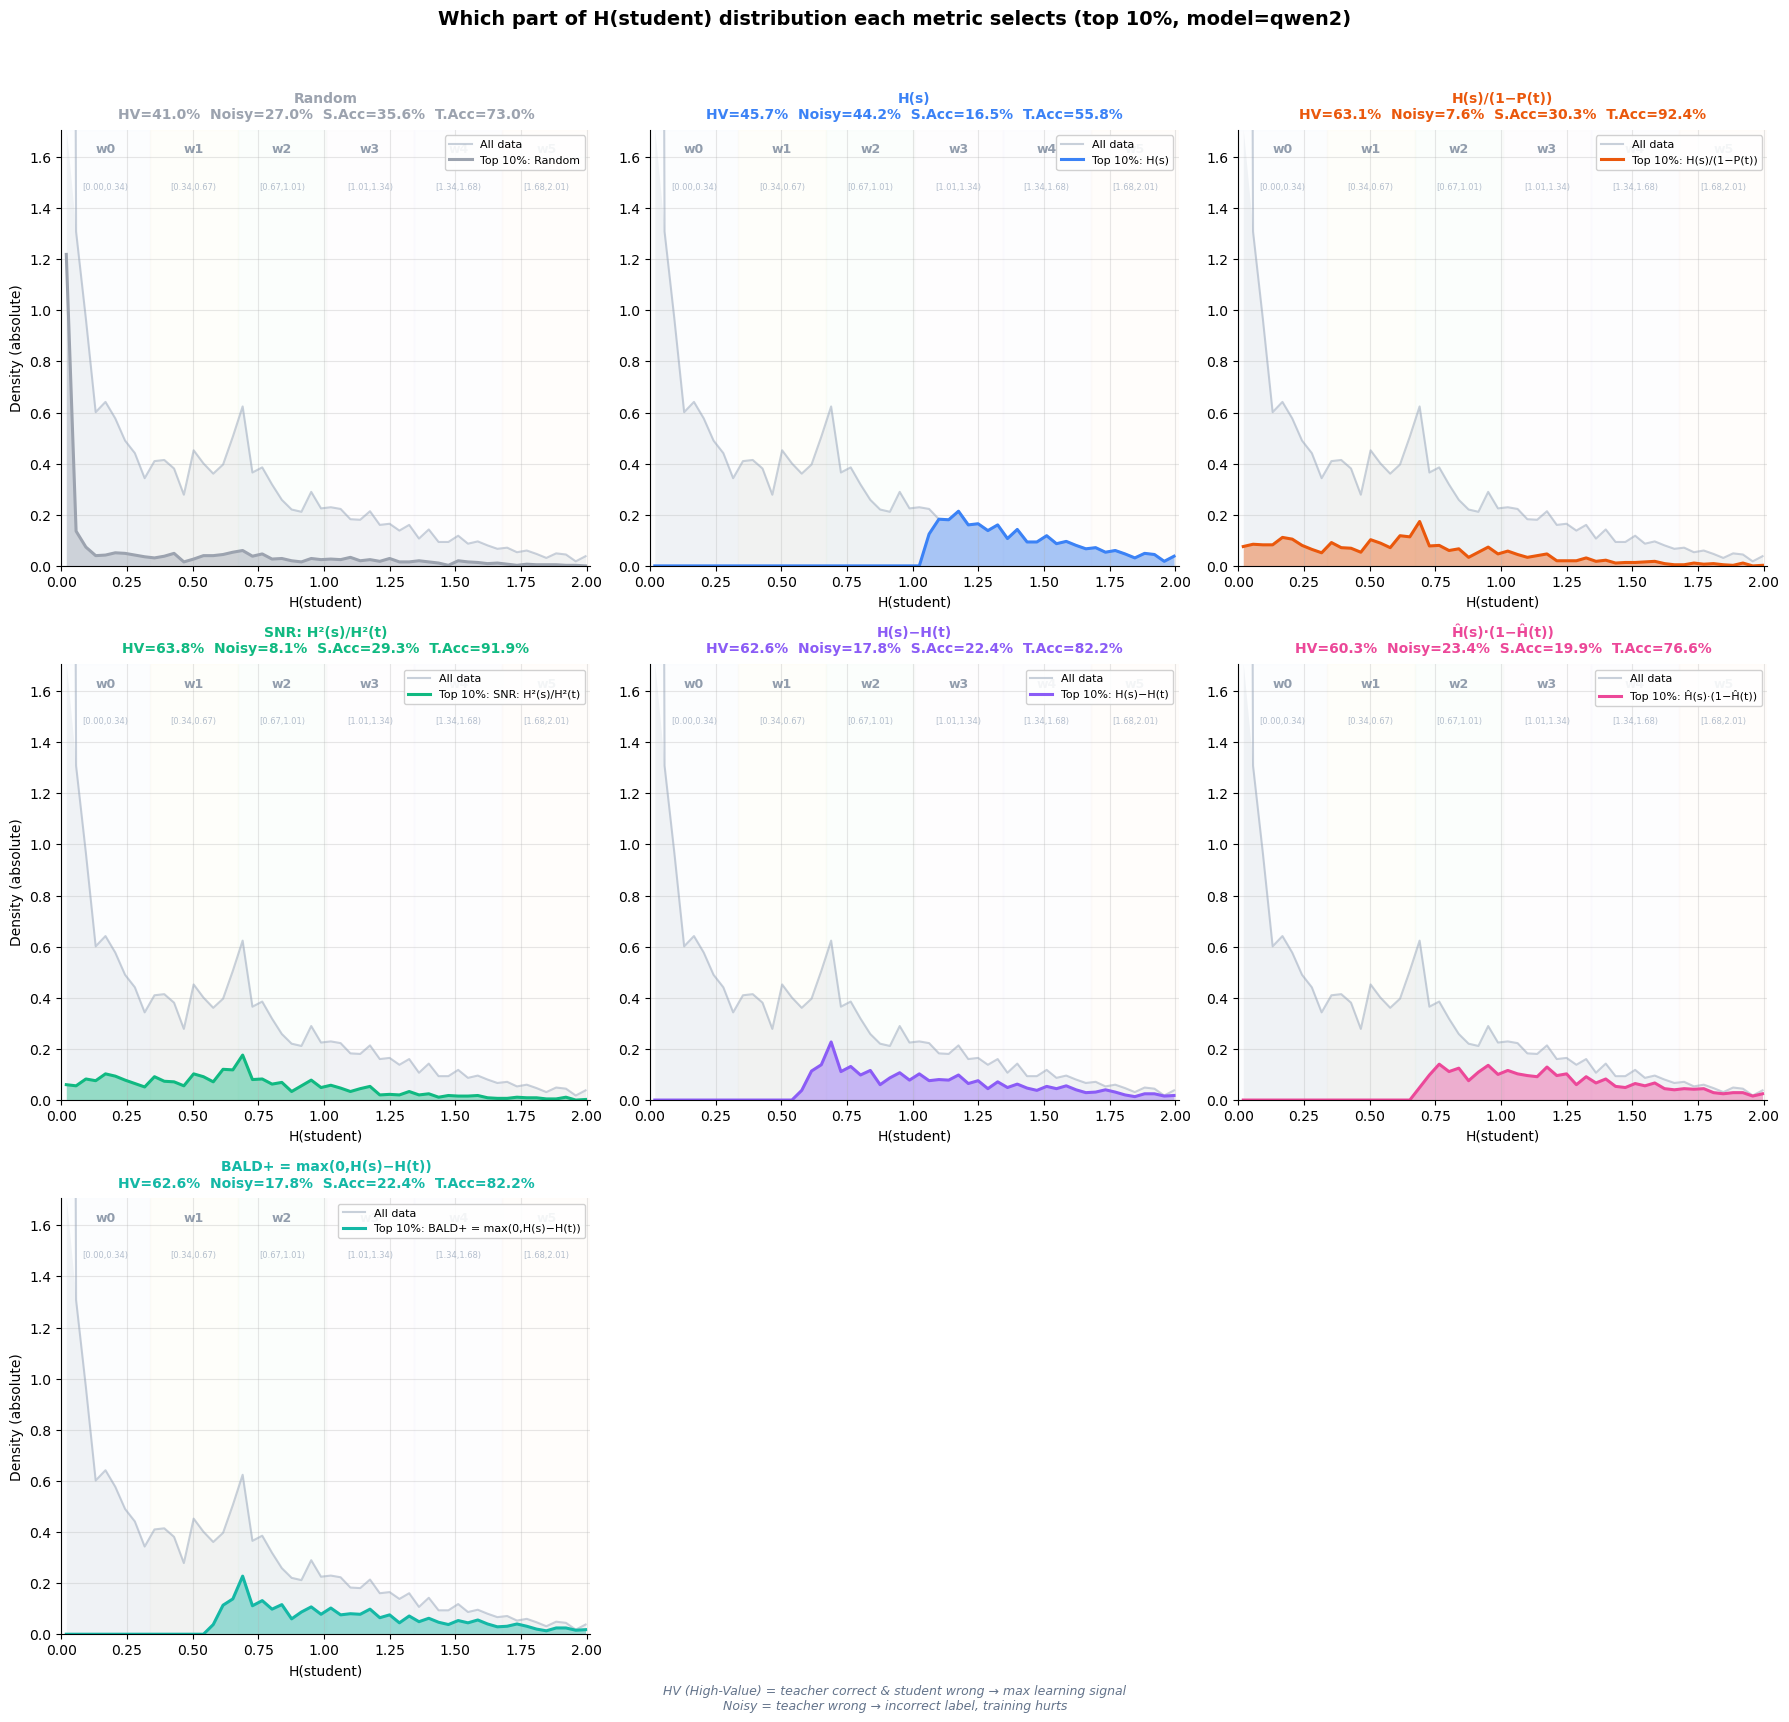

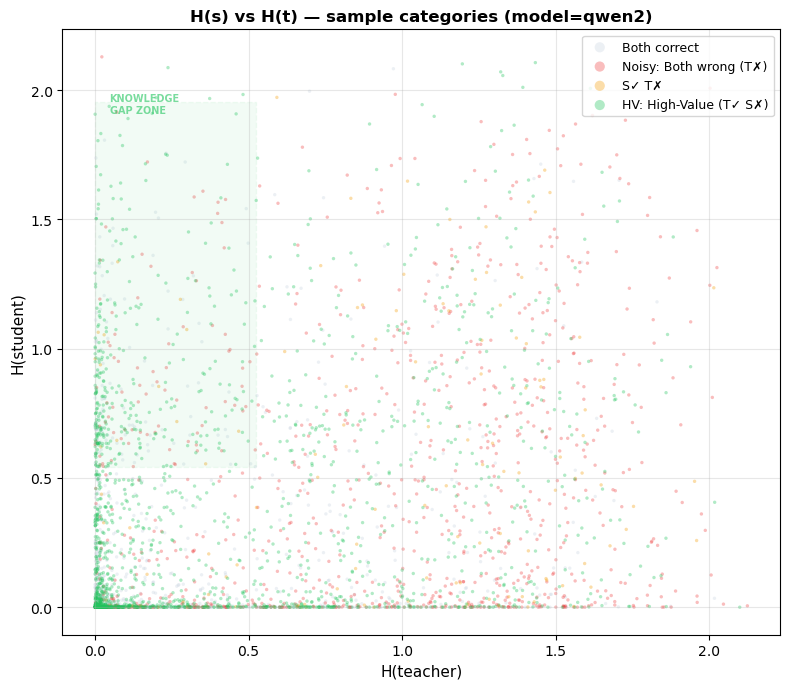

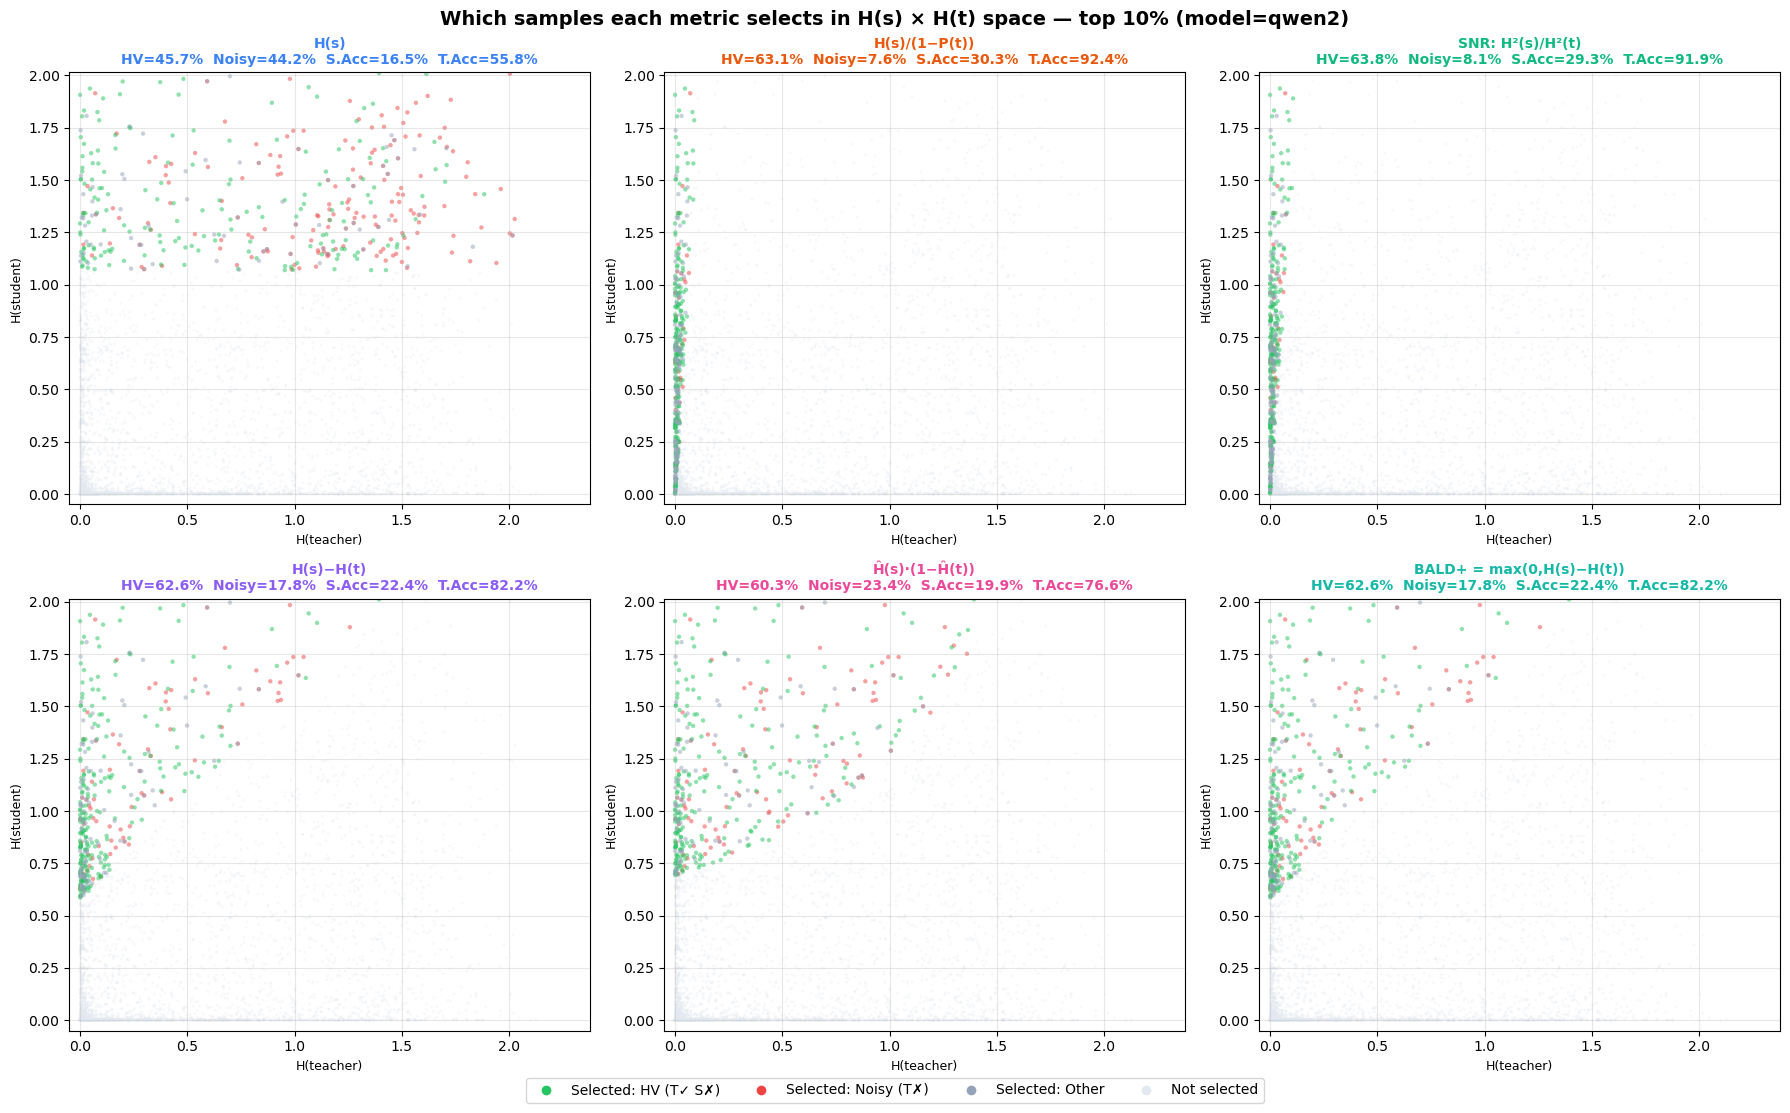


  SUMMARY

Metric ranking by High-Value Rate (top 10%, model=qwen2):

  HV  = High-Value: teacher correct & student wrong (max learning signal)
  Noisy = teacher wrong (incorrect label → training hurts)

  1. SNR: H²(s)/H²(t)               HV=63.8%, Noisy=8.1%, S.Acc=29.3%, T.Acc=91.9% ★
  2. H(s)/(1−P(t))                  HV=63.1%, Noisy=7.6%, S.Acc=30.3%, T.Acc=92.4%
  3. H(s)−H(t)                      HV=62.6%, Noisy=17.8%, S.Acc=22.4%, T.Acc=82.2%
  4. BALD+ = max(0,H(s)−H(t))       HV=62.6%, Noisy=17.8%, S.Acc=22.4%, T.Acc=82.2%
  5. Ĥ(s)·(1−Ĥ(t))                  HV=60.3%, Noisy=23.4%, S.Acc=19.9%, T.Acc=76.6%
  6. H(s)                           HV=45.7%, Noisy=44.2%, S.Acc=16.5%, T.Acc=55.8%
  7. Random                         HV=41.0%, Noisy=27.0%, S.Acc=35.6%, T.Acc=73.0%

All figures saved: fig1-fig5_*.png


In [ ]:
"""
Active Learning Metrics — full analysis
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

DATA_PATH = "merged.csv"  # ← change path if needed
model = "qwen2"            # ← "phi3" or "qwen2"

df = pd.read_csv(DATA_PATH, sep="\t")

if model == "qwen2":
    qwen = pd.read_csv("mmlu_qwen_3b.tsv", sep="\t")
    df["entropy_value_qwen2"] = df["question_id"].map(
        qwen.set_index("question_id")["entropy_value_qwen2"]
    )

H_s = df[f"entropy_value_{model}"].values
H_t = df["distill_entropy"].values
P_t = df["distill_answer_prob"].values
student_correct = df[f"entropy_ans_correct_{model}"].values.astype(bool)
teacher_correct = df["distill_ans_correct"].values.astype(bool)

# Sample categories
is_high_value   = teacher_correct & ~student_correct   
is_learnable    = teacher_correct                      
is_noisy        = ~teacher_correct                     
is_both_correct = teacher_correct & student_correct
is_student_only = ~teacher_correct & student_correct

print(f"Dataset: {len(df)} samples, model={model}")
print(f"Student accuracy: {student_correct.mean():.3f}")
print(f"Teacher accuracy: {teacher_correct.mean():.3f}")
print(f"High-Value:    {is_high_value.sum():>5} ({is_high_value.mean():.1%})")
print(f"Both correct:  {is_both_correct.sum():>5} ({is_both_correct.mean():.1%})")
print(f"Both wrong:    {(is_noisy & ~student_correct).sum():>5} ({(is_noisy & ~student_correct).mean():.1%})")
print(f"Student>Teach: {is_student_only.sum():>5} ({is_student_only.mean():.1%})")

EPS = 1e-8

H_s_max = H_s.max()
H_t_max = H_t.max()
Hs_n = H_s / H_s_max 
Ht_n = H_t / H_t_max

print(f"\nEntropy ranges: H(s) ∈ [0, {H_s_max:.2f}], H(t) ∈ [0, {H_t_max:.2f}]")
print(f"After normalization: Ĥ(s), Ĥ(t) ∈ [0, 1]")
print(f"Raw 1-H(t) < 0: {(1-H_t < 0).sum()} samples ({(1-H_t < 0).mean():.1%}) — broken without norm")
print(f"Norm 1-Ĥ(t) < 0: {(1-Ht_n < 0).sum()} samples — none\n")

metrics = {
    "Random":                np.random.RandomState(42).rand(len(df)),
    "H(s)":                  H_s,
    "H(s)/(1−P(t))":         H_s / np.maximum(1 - P_t, EPS),
    "SNR: H²(s)/H²(t)":      H_s**2 / np.maximum(H_t**2, EPS),
    "H(s)−H(t)":             H_s - H_t,
    "Ĥ(s)·(1−Ĥ(t))":        Hs_n * (1 - Ht_n),
    "BALD+ = max(0,H(s)−H(t))": np.maximum(H_s - H_t, 0),
}

COLORS = {
    "Random":                "#9ca3af",
    "H(s)":                  "#3b82f6",
    "H(s)/(1−P(t))":         "#ea580c",
    "SNR: H²(s)/H²(t)":      "#10b981",
    "H(s)−H(t)":             "#8b5cf6",
    "Ĥ(s)·(1−Ĥ(t))":        "#ec4899",
    "BALD+ = max(0,H(s)−H(t))": "#14b8a6",
}

def evaluate_at_k(scores, k_frac):
    """Select top k_frac% by score, compute quality metrics."""
    k = max(1, int(len(scores) * k_frac))
    idx = np.argsort(-scores)[:k]
    return {
        "high_value_rate": is_high_value[idx].mean(),
        "learnable_rate":  is_learnable[idx].mean(),
        "noisy_rate":      is_noisy[idx].mean(),
        "student_acc":     student_correct[idx].mean(),
        "teacher_acc":     teacher_correct[idx].mean(),
        "avg_H_s":         H_s[idx].mean(),
        "avg_H_t":         H_t[idx].mean(),
    }

K_FRACS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

results = {}
for name, scores in metrics.items():
    results[name] = {}
    for kf in K_FRACS:
        results[name][kf] = evaluate_at_k(scores, kf)

def print_table(k_frac=0.10):
    print(f"\n{'='*110}")
    print(f"  RANKING TABLE — top {int(k_frac*100)}%")
    print(f"{'='*110}")
    base_hv = results["Random"][k_frac]["high_value_rate"]
    header = f"{'Metric':<30} {'HV%':>7} {'Learn%':>8} {'Noisy%':>8} {'S.Acc':>7} {'T.Acc':>7} {'Lift':>8}"
    print(header)
    print("-" * 110)

    ranked = sorted(results.keys(), key=lambda n: -results[n][k_frac]["high_value_rate"])
    for i, name in enumerate(ranked, 1):
        r = results[name][k_frac]
        lift = (r["high_value_rate"] - base_hv) / base_hv * 100 if base_hv > 0 else 0
        lift_str = "baseline" if name == "Random" else f"{lift:+.1f}%"
        print(f"{i:>2}. {name:<26} {r['high_value_rate']*100:>6.1f}% {r['learnable_rate']*100:>7.1f}% "
              f"{r['noisy_rate']*100:>7.1f}% {r['student_acc']*100:>6.1f}% {r['teacher_acc']*100:>6.1f}% "
              f"{lift_str:>8}")

for kf in [0.05, 0.10, 0.20]:
    print_table(kf)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "sans-serif",
    "font.size": 10,
})

plot_metrics = list(metrics.keys())

# Adaptive entropy range (works for any model)
H_s_range = np.percentile(H_s, 99.5) * 1.05
H_t_range = H_t.max() * 1.05
print(f"\nPlot ranges: H(s) → [0, {H_s_range:.2f}], H(t) → [0, {H_t_range:.2f}]")

DEFINITIONS = (
    "HV (High-Value) = teacher correct & student wrong → max learning signal\n"
    "Noisy = teacher wrong → incorrect label, training hurts"
)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, key, title, ascending in [
    (axes[0], "high_value_rate", "High-Value Rate at top 10% (↑ better)", False),
    (axes[1], "noisy_rate", "Noisy Rate at top 10% (↓ better)", True),
]:
    kf = 0.10
    data = [(name, results[name][kf][key]) for name in metrics]
    data.sort(key=lambda x: x[1], reverse=not ascending)
    names = [d[0] for d in data]
    vals = [d[1] for d in data]
    colors = [COLORS[n] for n in names]

    bars = ax.barh(range(len(names)), vals, color=colors, edgecolor="white", linewidth=0.5, height=0.7)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9, fontfamily="monospace")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.invert_yaxis()

    base_val = results["Random"][kf][key]
    ax.axvline(base_val, color="#ef4444", linestyle="--", alpha=0.5, linewidth=1.2, label=f"Random ({base_val:.1%})")
    ax.legend(fontsize=8, loc="lower right" if not ascending else "lower left")

    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f"{val:.1%}", va="center", fontsize=9, fontfamily="monospace")

fig.text(0.5, -0.02, DEFINITIONS, ha="center", fontsize=9, color="#64748b", style="italic")
plt.tight_layout()
plt.savefig("fig1_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
fracs_pct = [int(kf * 100) for kf in K_FRACS]

for ax, key, title in [
    (axes[0], "high_value_rate", "High-Value Rate vs Budget"),
    (axes[1], "noisy_rate",      "Noisy Rate vs Budget"),
    (axes[2], "student_acc",     "Student Accuracy in Subset (ideal: low)"),
    (axes[3], "teacher_acc",     "Teacher Accuracy in Subset (ideal: high)"),
]:
    for name in plot_metrics:
        vals = [results[name][kf][key] for kf in K_FRACS]
        ax.plot(fracs_pct, vals, "o-", label=name, color=COLORS[name], linewidth=2, markersize=4)
    ax.set_xlabel("Selection Budget (%)")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=7, loc="best")

fig.text(0.5, -0.01, DEFINITIONS, ha="center", fontsize=9, color="#64748b", style="italic")
plt.tight_layout()
plt.savefig("fig2_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

dist_metrics = list(metrics.keys())
bins = np.linspace(0, H_s_range, 55)
bin_centers = (bins[:-1] + bins[1:]) / 2
bw = bins[1] - bins[0]
N = len(df)

full_counts, _ = np.histogram(H_s, bins=bins)
full_abs = full_counts / (N * bw)

sel_abs_all = {}
for name in dist_metrics:
    k = max(1, int(N * 0.10))
    idx = np.argsort(-metrics[name])[:k]
    sc, _ = np.histogram(H_s[idx], bins=bins)
    sel_abs_all[name] = sc / (N * bw)

y_max_sel = max(sd.max() for sd in sel_abs_all.values())
y_max = y_max_sel * 1.4

n_wbins = 6
wbin_edges = np.linspace(0, H_s_range, n_wbins + 1)
wbin_colors = ["#dbeafe", "#fef3c7", "#d1fae5", "#fce7f3", "#ede9fe", "#ffedd5"]

nrows = (len(dist_metrics) + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(18, 5.5 * nrows))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, dist_metrics)):
    sd = sel_abs_all[name]

    for wi in range(n_wbins):
        ax.axvspan(wbin_edges[wi], wbin_edges[wi+1], alpha=0.08, color=wbin_colors[wi], zorder=0)
        mid = (wbin_edges[wi] + wbin_edges[wi+1]) / 2
        ax.text(mid, y_max * 0.97, f"w{wi}", ha="center", va="top",
                fontsize=9, fontweight="bold", color="#64748b", alpha=0.7)
        ax.text(mid, y_max * 0.88, f"[{wbin_edges[wi]:.2f},{wbin_edges[wi+1]:.2f})",
                ha="center", va="top", fontsize=6, color="#94a3b8", alpha=0.7)

    ax.fill_between(bin_centers, np.minimum(full_abs, y_max), alpha=0.12, color="#94a3b8", linewidth=0)
    ax.plot(bin_centers, full_abs, color="#94a3b8", linewidth=1.5, alpha=0.5,
            label="All data", clip_on=True)

    ax.fill_between(bin_centers, sd, alpha=0.4, color=COLORS[name], linewidth=0)
    ax.plot(bin_centers, sd, color=COLORS[name], linewidth=2.2, label=f"Top 10%: {name}")

    r = results[name][0.10]
    ax.set_title(f"{name}\nHV={r['high_value_rate']:.1%}  Noisy={r['noisy_rate']:.1%}  "
                 f"S.Acc={r['student_acc']:.1%}  T.Acc={r['teacher_acc']:.1%}",
                 fontsize=10, fontweight="bold", color=COLORS[name], pad=8)
    ax.set_xlabel("H(student)", fontsize=10)
    if i % 3 == 0:
        ax.set_ylabel("Density (absolute)", fontsize=10)
    ax.legend(fontsize=8, framealpha=0.9, loc="upper right")
    ax.set_xlim(0, H_s_range)
    ax.set_ylim(0, y_max)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(len(dist_metrics), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Which part of H(student) distribution each metric selects (top 10%, model={model})",
             fontsize=14, fontweight="bold", y=1.02)
fig.text(0.5, -0.01, DEFINITIONS, ha="center", fontsize=9, color="#64748b", style="italic")
plt.tight_layout()
plt.savefig("fig3_entropy_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


rng = np.random.RandomState(42)
sample_idx = rng.choice(len(df), min(4000, len(df)), replace=False)

fig, ax = plt.subplots(figsize=(8, 7))

cats = np.full(len(df), "other", dtype=object)
cats[is_high_value] = "high_value"
cats[is_noisy & ~student_correct] = "noisy"
cats[is_student_only] = "student_only"
cat_colors = {"high_value": "#22c55e", "noisy": "#ef4444", "student_only": "#f59e0b", "other": "#cbd5e1"}
cat_labels = {"high_value": "HV: High-Value (T✓ S✗)", "noisy": "Noisy: Both wrong (T✗)",
              "student_only": "S✓ T✗", "other": "Both correct"}

for cat in ["other", "noisy", "student_only", "high_value"]:
    mask = cats[sample_idx] == cat
    ax.scatter(H_t[sample_idx][mask], H_s[sample_idx][mask],
              c=cat_colors[cat], s=6, alpha=0.35, label=cat_labels[cat], edgecolors="none")

ax.set_xlabel("H(teacher)", fontsize=11)
ax.set_ylabel("H(student)", fontsize=11)
ax.set_title(f"H(s) vs H(t) — sample categories (model={model})", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, markerscale=3)

ax.add_patch(Rectangle((0, H_s_range * 0.27), H_t_range * 0.22, H_s_range * 0.7,
             fill=True, facecolor="#22c55e", alpha=0.06,
             edgecolor="#22c55e", linewidth=1, linestyle="--"))
ax.text(H_t_range * 0.02, H_s_range * 0.95, "KNOWLEDGE\nGAP ZONE",
        fontsize=7, color="#22c55e", alpha=0.6, fontweight="bold")

plt.tight_layout()
plt.savefig("fig4_scatter_categories.png", dpi=150, bbox_inches="tight")
plt.show()


scatter_metrics = [n for n in metrics if n != "Random"]

nrows_sc = (len(scatter_metrics) + 2) // 3
fig, axes = plt.subplots(nrows_sc, 3, figsize=(18, 5.5 * nrows_sc))
axes = axes.flatten()

for ax, name in zip(axes, scatter_metrics):
    scores = metrics[name]
    k = max(1, int(len(df) * 0.10))
    top_idx = set(np.argsort(-scores)[:k])
    is_sel = np.array([i in top_idx for i in sample_idx])

    ax.scatter(H_t[sample_idx][~is_sel], H_s[sample_idx][~is_sel],
              c="#e2e8f0", s=4, alpha=0.3, edgecolors="none")

    sel_mask = sample_idx[is_sel]
    for cat, color in [("noisy", "#ef4444"), ("high_value", "#22c55e"), ("other", "#94a3b8")]:
        if cat == "high_value":
            cm = is_high_value[sel_mask]
        elif cat == "noisy":
            cm = is_noisy[sel_mask]
        else:
            cm = is_both_correct[sel_mask] | is_student_only[sel_mask]
        ax.scatter(H_t[sel_mask][cm], H_s[sel_mask][cm],
                  c=color, s=10, alpha=0.5, edgecolors="none")

    r = results[name][0.10]
    ax.set_title(f"{name}\nHV={r['high_value_rate']:.1%}  Noisy={r['noisy_rate']:.1%}  "
                 f"S.Acc={r['student_acc']:.1%}  T.Acc={r['teacher_acc']:.1%}",
                fontsize=10, fontweight="bold", color=COLORS[name])
    ax.set_xlabel("H(teacher)", fontsize=9)
    ax.set_ylabel("H(student)", fontsize=9)
    ax.set_xlim(-0.05, H_t_range)
    ax.set_ylim(-0.05, H_s_range)

for j in range(len(scatter_metrics), len(axes)):
    axes[j].set_visible(False)

legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#22c55e", markersize=8, label="Selected: HV (T✓ S✗)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#ef4444", markersize=8, label="Selected: Noisy (T✗)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#94a3b8", markersize=8, label="Selected: Other"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#e2e8f0", markersize=8, label="Not selected"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle(f"Which samples each metric selects in H(s) × H(t) space — top 10% (model={model})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_scatter_per_metric.png", dpi=150, bbox_inches="tight")
plt.show()


print("\n" + "=" * 80)
print("  SUMMARY")
print("=" * 80)

r10 = {n: results[n][0.10] for n in metrics}
ranked = sorted(r10.keys(), key=lambda n: -r10[n]["high_value_rate"])
print(f"\nMetric ranking by High-Value Rate (top 10%, model={model}):\n")
print(f"  HV  = High-Value: teacher correct & student wrong (max learning signal)")
print(f"  Noisy = teacher wrong (incorrect label → training hurts)\n")
for i, name in enumerate(ranked, 1):
    r = r10[name]
    star = " ★" if i == 1 else ""
    print(f"  {i}. {name:<30} HV={r['high_value_rate']:.1%}, Noisy={r['noisy_rate']:.1%}, "
          f"S.Acc={r['student_acc']:.1%}, T.Acc={r['teacher_acc']:.1%}{star}")

print(f"\nAll figures saved: fig1-fig5_*.png")